# Inkscape MCP Demo

This notebook demonstrates AI-powered SVG generation using the **inkscape-mcp** server and the **Recraft API**.

## Model note
The README Quick Example uses `model="flux-dev"`, which is currently a placeholder with no API behind it.  
Use `model="nano-banana-pro"` to trigger a real call to the **Recraft vector generation API**.

## Two approaches shown
1. **Direct** — import `_call_recraft_api` and call it directly (no MCP server needed)
2. **Via MCP** — call the `generate_svg` tool through the running inkscape-mcp HTTP server

## Setup

In [1]:
import os
from pathlib import Path
from IPython.display import SVG, display, HTML
import inkscape_mcp

In [2]:
# Inkscape executable path (auto-detected if not set)
os.environ["INKSCAPE_PATH"] = "/usr/bin/inkscape"

# Default SVG output directory
os.environ["INKSCAPE_OUTPUT_DIR"] = "./output"

# Logging level
os.environ["INKSCAPE_LOG_LEVEL"] = "INFO"

# Timeout for Inkscape operations (seconds)
os.environ["INKSCAPE_TIMEOUT"] = "30"

# Verify RECRAFT_API_TOKEN is available (injected from .env by Docker)
token = os.environ.get("RECRAFT_API_TOKEN", "").strip()
if not token or token == "your_key_here":
    print("⚠️  RECRAFT_API_TOKEN is not set or still has the placeholder value.")
    print("   Edit .env with your real key and restart the Docker services.")
else:
    print(f"✅ RECRAFT_API_TOKEN is set ({token[:8]}{'*' * 8})")

✅ RECRAFT_API_TOKEN is set (7XNYrs9K********)


---
## Approach 1 — Direct Recraft API call

Imports `_call_recraft_api` from `inkscape_mcp.agentic` and calls it directly.
No MCP server required — useful for testing the API integration in isolation.

In [3]:
# Debug: preview the request payload before sending
from inkscape_mcp.agentic import _RECRAFT_QUALITY_MODEL, _nearest_recraft_aspect

model = _RECRAFT_QUALITY_MODEL.get("high", "recraftv4_vector")
size  = _nearest_recraft_aspect(600, 800)
print(f"model : {model}")
print(f"size  : {size}")
print(f"style : (omitted for V4 models)")
print(f"token : {os.environ.get('RECRAFT_API_TOKEN','')[:8]}...")


model : recraftv4_pro_vector
size  : 3:4
style : (omitted for V4 models)
token : 7XNYrs9K...


In [4]:
from inkscape_mcp.agentic import _call_recraft_api

print("Calling Recraft API...")
svg_content = await _call_recraft_api(
    description="coat of arms with lions rampant and a golden crown",
    style_preset="heraldic",
    width=600,
    height=800,
    quality="high",   # high -> recraftv4_pro_vector
)
print(f"✅ Generated SVG ({len(svg_content):,} bytes)")


2026-03-15 19:49:00.484 | INFO     | inkscape_mcp.agentic:_call_recraft_api:101 | Calling Recraft API: model=recraftv4_pro_vector, style=None, size=3:4


Calling Recraft API...


2026-03-15 19:49:34.096 | INFO     | inkscape_mcp.agentic:_call_recraft_api:121 | Recraft generation complete, downloading SVG from https://img.recraft.ai/iYygizQtLGzacW_J0eyc-GOjb-m6eexU6gz2JnoVSyI/rs:fit:1792:2432:0/raw:1/plain/abs://external/images/610c7296-7138-4302-9b42-d171bd841be5


✅ Generated SVG (137,123 bytes)


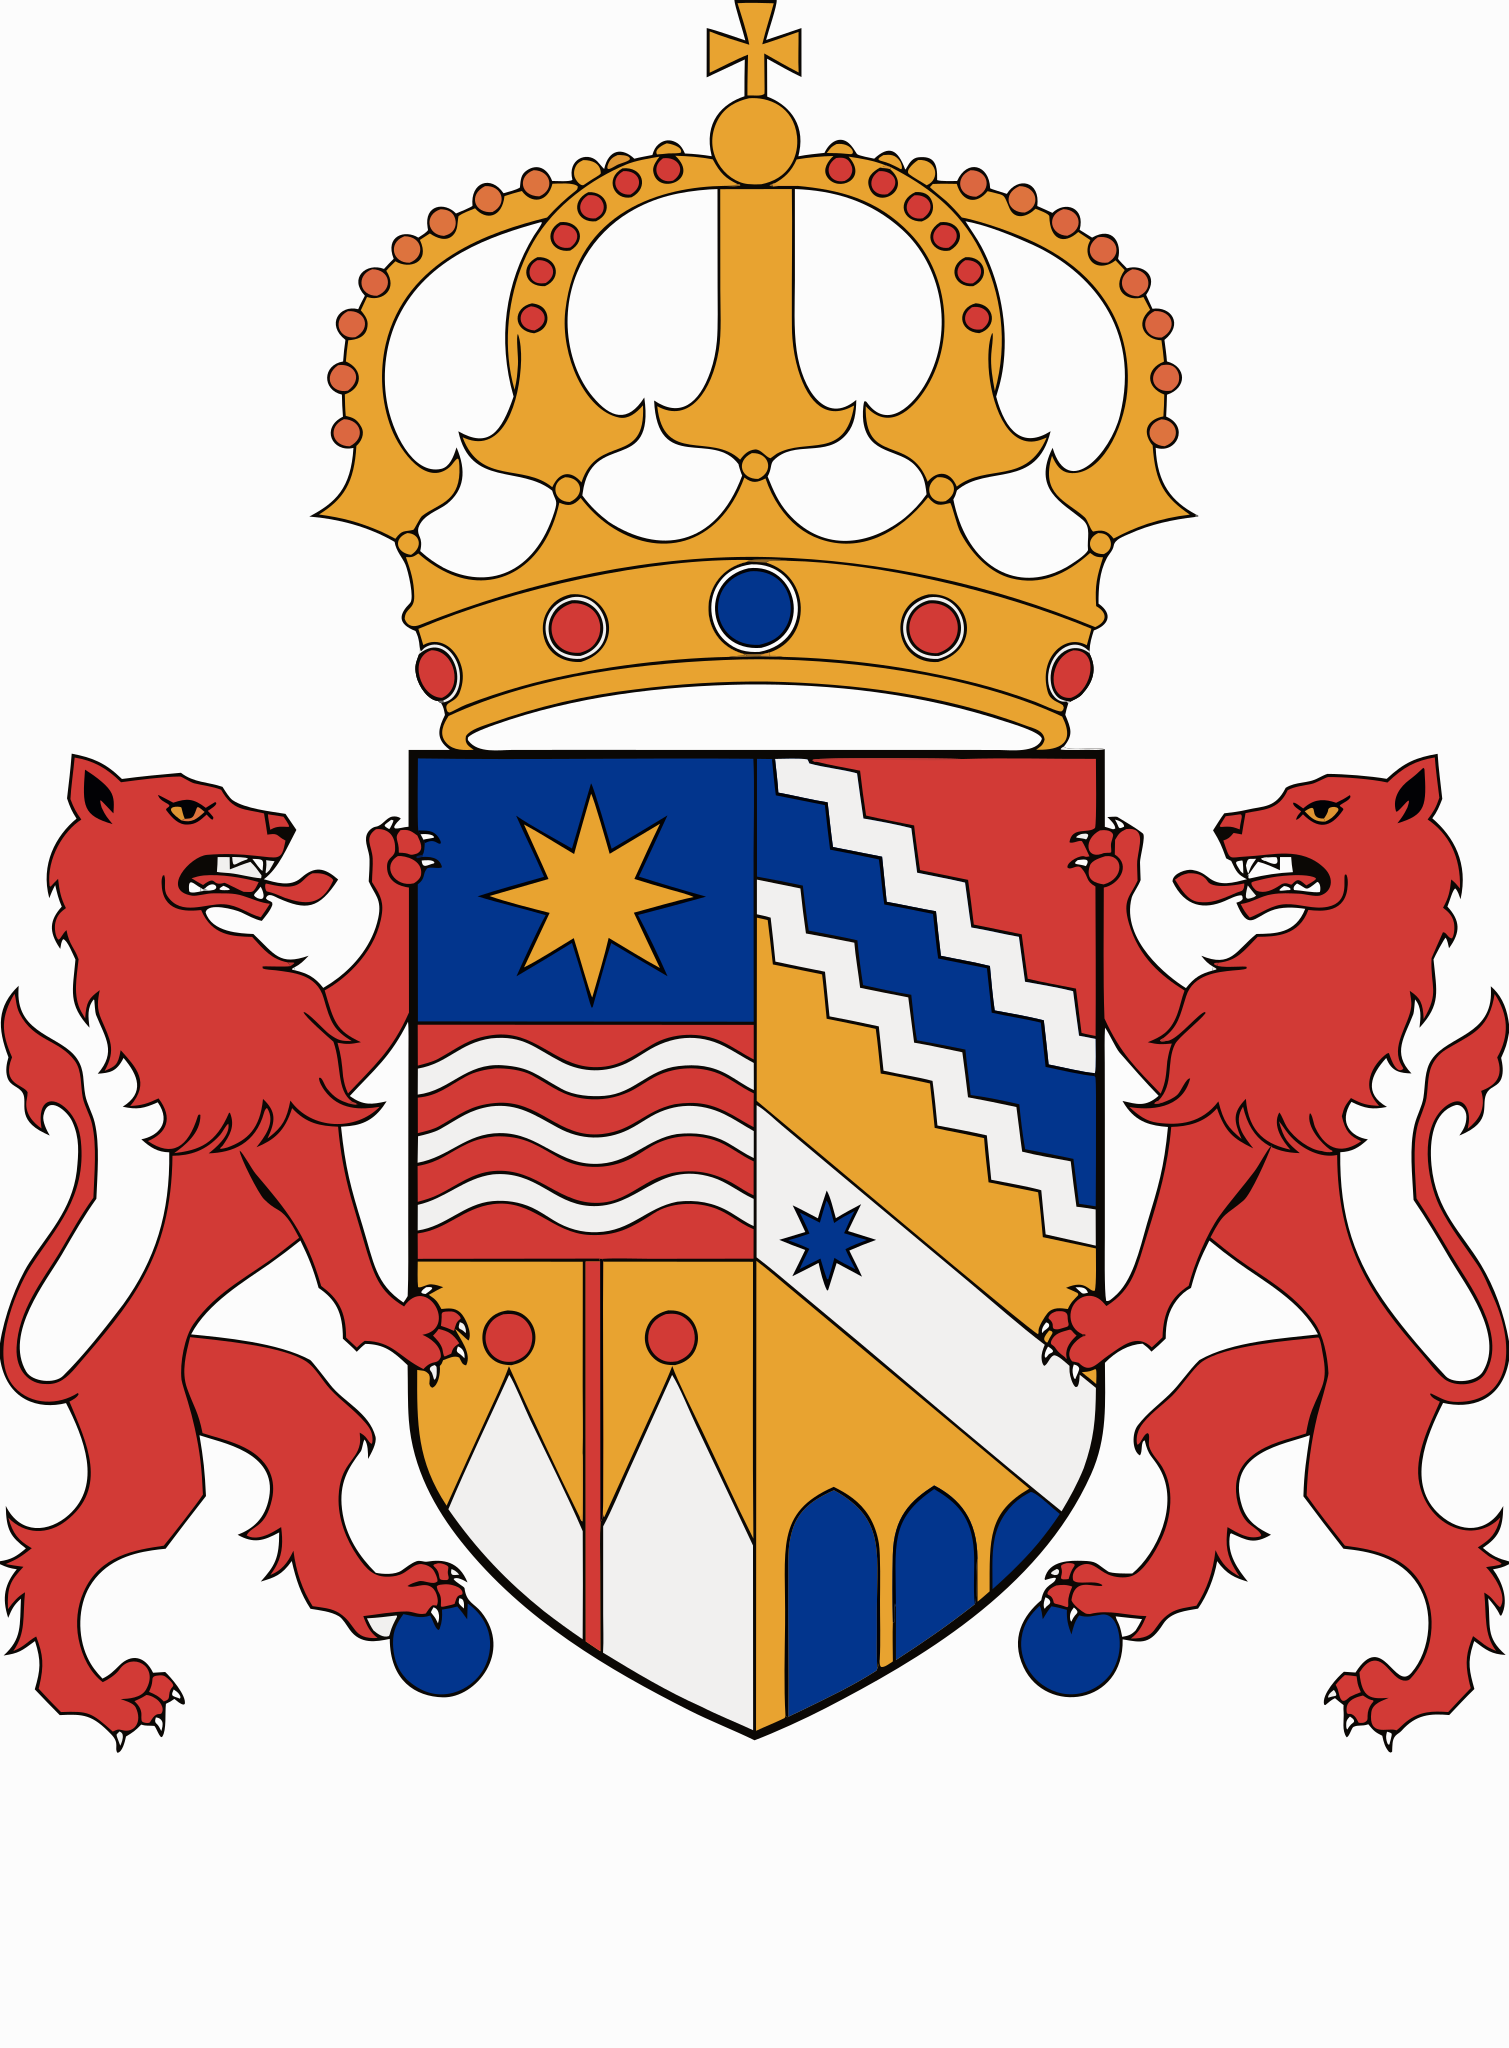

Saved to generated_svgs/coat_of_arms_direct.svg


In [5]:
# Display the SVG inline
display(SVG(data=svg_content))

# Save to disk
output_path = Path("generated_svgs/coat_of_arms_direct.svg")
output_path.parent.mkdir(exist_ok=True)
output_path.write_text(svg_content, encoding="utf-8")
print(f"Saved to {output_path}")

---
## Approach 2 — Via MCP server (`generate_svg` tool)

Connects to the running `inkscape-mcp` service (Docker service name: `inkscape-mcp`, port `8000`)  
and calls the `generate_svg` MCP tool — exactly as an AI assistant would invoke it.

This is the equivalent of the README Quick Example:
```python
generate_svg(
    description="coat of arms with lions rampant and a golden crown",
    style_preset="heraldic",
    dimensions="600x800",
    model="nano-banana-pro",   # <-- use this, not flux-dev
    quality="high",
    post_processing=["simplify", "optimize"]
)
```

In [6]:
from fastmcp import Client

# When running inside Docker Compose the MCP server is reachable at its service name.
# Change to http://localhost:8000 if running the notebook outside Docker.
# FastMCP streamable-HTTP transport mounts at /mcp
MCP_SERVER_URL = "http://inkscape-mcp:8000/mcp"

print("Calling generate_svg via MCP server...")
async with Client(MCP_SERVER_URL) as client:
    mcp_result = await client.call_tool(
        "generate_svg",
        {
            "description": "coat of arms with lions rampant and a golden crown",
            "style_preset": "heraldic",
            "dimensions": "600x800",
            "model": "nano-banana-pro",
            "quality": "high",
            "post_processing": ["simplify", "optimize"],
        },
    )
print(mcp_result)


Calling generate_svg via MCP server...


[03/15/26 19:49:34] INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=381956;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=843976;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in heraldic style...', 'extra': None}                                 

[03/15/26 19:50:08] INFO     Received INFO from server: {'msg': '🎨 Applying Inkscape                 ]8;id=850543;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=829814;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             post-processing: simplify, optimize', 'extra': None}                                  

                    INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=924819;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=893230;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_194934_c3d8352d_600x800_processed.svg', 'extra': None}                

CallToolResult(content=[TextContent(type='text', text='{"success":true,"message":"Successfully generated heraldic SVG: \'coat of arms with lions rampant and a golden crown...\'","svg_path":"generated_svgs/ai_20260315_194934_c3d8352d_600x800_processed.svg","svg_hash":"5c5df737","dimensions":"600x800","style_preset":"heraldic","model_used":"nano-banana-pro","quality_level":"high","processing_applied":["simplify","optimize"],"quality_metrics":{"overall_quality":5.0,"file_size_kb":159.31,"element_count":357,"path_count":350,"group_count":0,"complexity_score":1.0,"size_efficiency":0.0,"format":"SVG","compression":"none"},"file_size_kb":159.31,"next_steps":["Use inkscape_vector tool for path manipulation","Apply inkscape_color for color adjustments","Use inkscape_transform for geometric modifications","Export with inkscape_file in different formats"]}', annotations=None, meta=None)], structured_content={'success': True, 'message': "Successfully generated heraldic SVG: 'coat of arms with lion

✅ SVG saved by server at: generated_svgs/ai_20260315_194934_c3d8352d_600x800_processed.svg


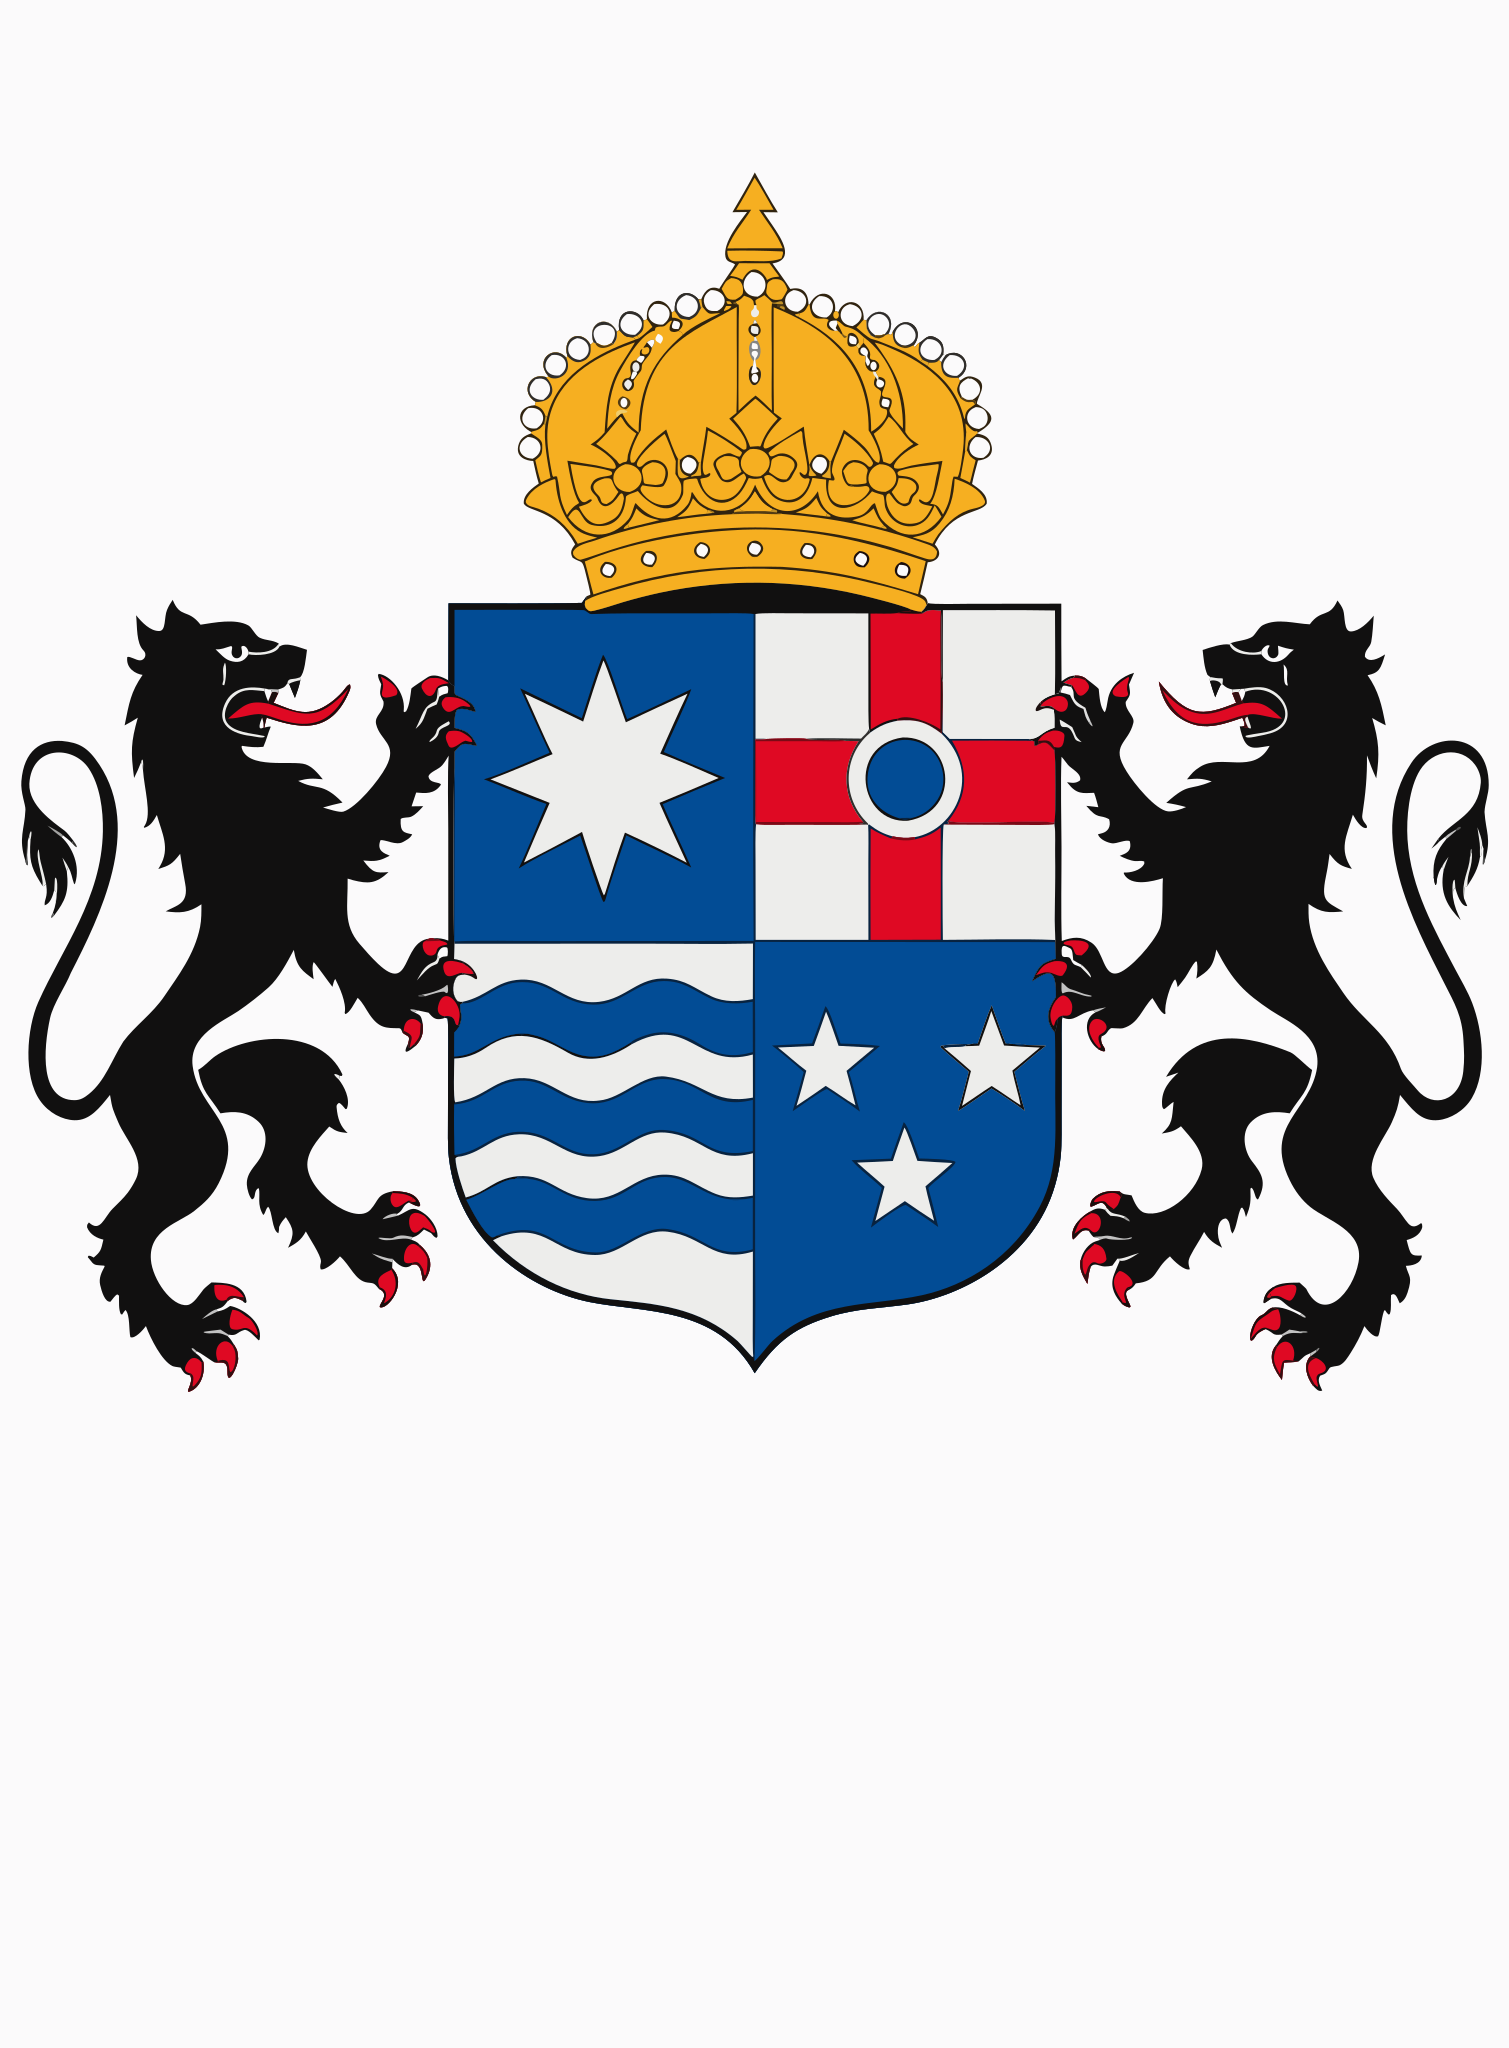

In [7]:
# The MCP result contains the path to the saved SVG.
# CallToolResult has .data (parsed dict), .content (list of TextContent), and .is_error

if mcp_result.is_error:
    print(f'❌ Tool returned an error: {mcp_result.data}')
else:
    payload = mcp_result.data  # already a dict — no JSON parsing needed
    if payload and payload.get('success'):
        svg_path = Path(payload['svg_path'])
        if svg_path.exists():
            mcp_svg = svg_path.read_text(encoding='utf-8')
            print(f'✅ SVG saved by server at: {svg_path}')
            display(SVG(data=mcp_svg))
        else:
            print(f'Server reported path {svg_path} but file not found in this container.')
            print('Hint: both services share the generated_svgs Docker volume.')
    else:
        print(f'❌ Generation failed: {payload.get("error") if payload else mcp_result}')


---
## Quality / model reference

| `quality` param | Recraft model used | Notes |
|---|---|---|
| `draft` | `recraftv4_vector` | Fast, good for iteration |
| `standard` | `recraftv4_vector` | Default |
| `high` | `recraftv4_pro_vector` | Higher fidelity, slower |
| `ultra` | `recraftv4_pro_vector` | Same model as high |

| `model` param | Behaviour |
|---|---|
| `nano-banana-pro` | Calls Recraft API (requires `RECRAFT_API_TOKEN`) |
| `flux-dev` | Falls back to local placeholder SVG — **not yet implemented** |

---
## Advanced Example — inkscape-mcp in Action

The example below uses the MCP server's **portmanteau tools** to chain operations:
`generate_svg` → `inkscape_file validate` → `inkscape_vector path_simplify` → `inkscape_file convert` (PDF export).

### Shared helpers

In [8]:
from fastmcp import Client
from pathlib import Path
from IPython.display import SVG, Image, display, HTML
import json, os

MCP = "http://inkscape-mcp:8000/mcp"

async def tool(name, **kwargs):
    """Call any MCP tool and return its .data dict.

    Raises RuntimeError for both MCP-level errors and application-level
    failures (i.e. when the returned dict has success=False).
    """
    async with Client(MCP) as c:
        result = await c.call_tool(name, kwargs)
    if result.is_error:
        raise RuntimeError(f"{name} MCP error: {result.data}")
    data = result.data
    if isinstance(data, dict) and not data.get("success", True):
        raise RuntimeError(
            f"{name} failed: {data.get('error', data.get('message', data))}"
        )
    return data

def show_svg(path):
    """Display an SVG file inline."""
    p = Path(path)
    if p.exists():
        display(SVG(data=p.read_text()))
    else:
        print(f"⚠️  File not found: {path}")

print("✅ Helpers ready")

✅ Helpers ready


---
## List Available Inkscape Extensions

The `inkscape_system_tool` with `operation="list_extensions"` queries the
Inkscape extension registry and returns every installed extension with its
id, name, category, and parameters.  
After the [xvfb fix](../src/inkscape_mcp/cli_wrapper.py) these extensions can also
be **executed headlessly** via `operation="execute_extension"`.


In [9]:
# ── List all available Inkscape extensions via the MCP server ────────────
result     = await tool("inkscape_system_tool", operation="list_extensions")
extensions = result["data"]["extensions"]
categories = result["data"]["categories"]

print(f"Found {result['data']['total_count']} extensions across {len(categories)} categories")
print(f"Categories: {', '.join(categories)}\n")

# ── HTML summary table ────────────────────────────────────────────────────
from IPython.display import HTML, display

rows = ""
for ext in sorted(extensions, key=lambda e: (e.get("category", ""), e.get("name", ""))):
    n_params = len(ext.get("parameters", []))
    rows += (
        f"<tr>"
        f"<td><code>{ext.get('id', '')}</code></td>"
        f"<td>{ext.get('name', '')}</td>"
        f"<td><b>{ext.get('category', '')}</b></td>"
        f"<td style='text-align:center'>{n_params}</td>"
        f"</tr>\n"
    )

display(HTML(f"""
<style>table{{border-collapse:collapse;font-size:12px}}
th,td{{border:1px solid #ddd;padding:3px 8px}}
th{{background:#f0f0f0}}tr:nth-child(even){{background:#fafafa}}</style>
<table>
  <thead><tr>
    <th>Extension ID</th><th>Name</th><th>Category</th><th>#&nbsp;Params</th>
  </tr></thead>
  <tbody>{rows}</tbody>
</table>
"""))

# ── Biology-relevant extensions ───────────────────────────────────────────
bio_keywords = (
    "barcode", "qr", "render", "generate", "diagram", "chart", "plot",
    "fractal", "spiral", "grid", "color", "colour", "gradient", "interpolate",
    "scatter", "heatmap", "pattern", "label", "legend", "scale bar",
)
bio_relevant = [
    e for e in extensions
    if any(
        kw in e.get("name", "").lower() or kw in e.get("id", "").lower()
        for kw in bio_keywords
    )
]
print(f"\n{len(bio_relevant)} extensions potentially useful for biology figures:")
for e in sorted(bio_relevant, key=lambda e: e.get("name", "")):
    params = ", ".join(p['name'] for p in e.get('parameters', [])[:3])
    if len(e.get('parameters', [])) > 3:
        params += f" (+{len(e['parameters'])-3} more)"
    print(f"  [{e.get('category','?'):18s}] {e.get('name',''):35s}  params: {params}")


Found 155 extensions across 15 categories
Categories: arrange, color, document, export, general, generate_from_path, images, jessyink, modify_path, render, styles, text, typography, visualize_path, web



Extension ID,Name,Category,# Params
mcepl.ungroup_deep,Deep Ungroup,arrange,4
org.inkscape.filter.restack,Restack,arrange,7
org.inkscape.color.black_and_white,Black and White,color,1
org.inkscape.color.brighter,Brighter,color,0
org.inkscape.color.custom,Custom,color,5
org.inkscape.color.darker,Darker,color,0
org.inkscape.color.desaturate,Desaturate,color,0
org.inkscape.color.grayscale,Grayscale,color,0
org.inkscape.color.hsl_adjust,HSL Adjust,color,7
org.inkscape.color.less_hue,Less Hue,color,0



50 extensions potentially useful for biology figures:
  [render            ] 3D Polyhedron                        params: tab, obj, spec_file (+28 more)
  [color             ] Black and White                      params: threshold
  [color             ] Brighter                             params: 
  [render            ] Calendar                             params: tab, year, month (+23 more)
  [render            ] Cartesian Grid                       params: border_th, border_th_unit, tab (+22 more)
  [render            ] Classic                              params: type, text, height
  [styles            ] Color Markers                        params: tab, type, invert (+7 more)
  [color             ] Custom                               params: tab, r, g (+2 more)
  [color             ] Darker                               params: 
  [render            ] Datamatrix                           params: text, symbol, size
  [color             ] Desaturate                           params

---
## Execute Inkscape Extensions via inkscape-mcp

Extensions are called via `inkscape_system_tool` with `operation="execute_extension"`.
The server invokes each extension's Python script directly — headlessly, no display needed.

Two biology-relevant examples:
1. **L-system** — Lindenmayer systems mathematically model plant branching, bacterial colony growth, and vascular networks
2. **Spirograph** — models cyclic biological structures such as flagellar motion, phyllotaxis, and mollusc shell geometries


L-system OK — 1,550,367 bytes


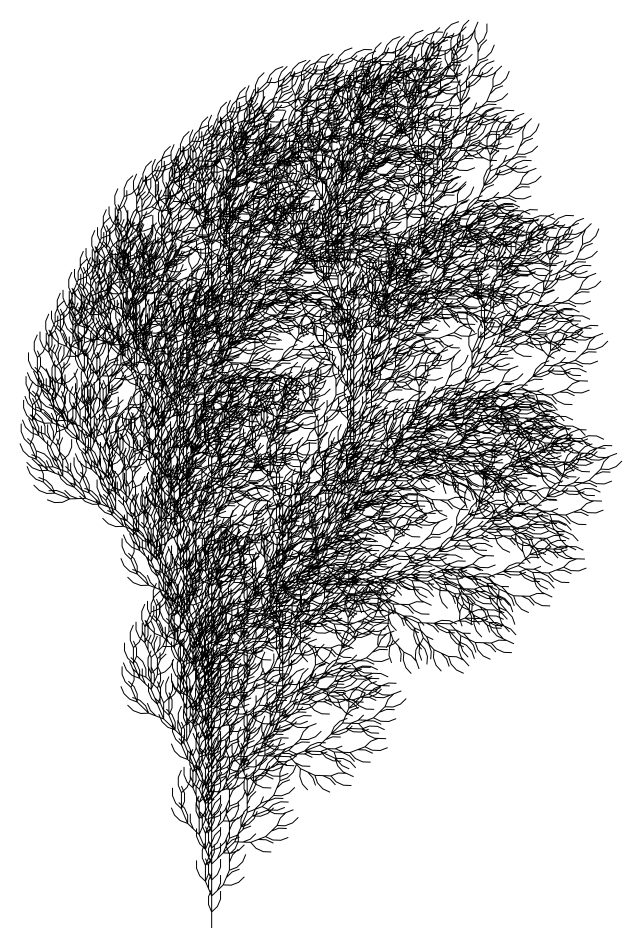

Spirograph OK — 28,697 bytes


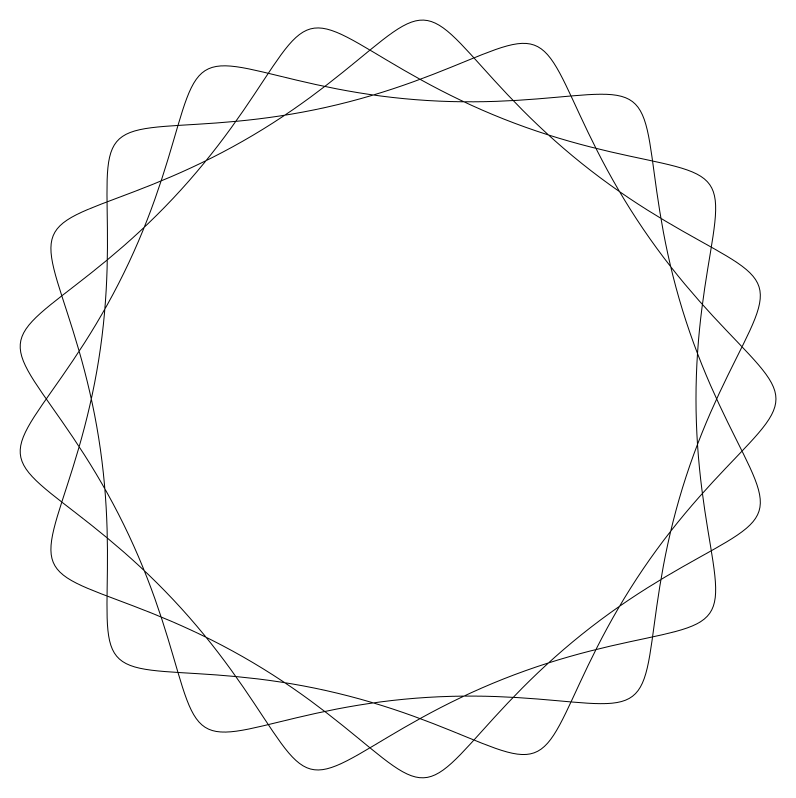

In [10]:
import re
from pathlib import Path
from IPython.display import SVG, display, HTML

# In the Jupyter container the shared generated_svgs volume is at /notebooks/generated_svgs.
# The MCP server container sees the same volume at /app/generated_svgs.
# Write the blank canvas and read results from the notebook-side path;
# pass the server-side path as output_file so the server writes there.
NB_OUT  = Path("/notebooks/generated_svgs")  # notebook container path
SRV_OUT = "/app/generated_svgs"               # MCP server container path
NB_OUT.mkdir(exist_ok=True)

# A minimal blank SVG canvas — render extensions add geometry into an existing document
BLANK_SVG = (
    '<?xml version="1.0" encoding="UTF-8"?>'
    '<svg xmlns="http://www.w3.org/2000/svg" width="500" height="500" viewBox="0 0 500 500"/>'
)
Path(NB_OUT / "blank_canvas.svg").write_text(BLANK_SVG)
blank_srv = f"{SRV_OUT}/blank_canvas.svg"  # server-side path for this same file


def fit_viewbox(svg_path: Path, padding: int = 20) -> None:
    """Rewrite viewBox/width/height to tightly fit all <path> content.

    L-system (and similar turtle-graphics) extensions draw starting from the
    SVG origin and typically extend into negative coordinates, placing the
    entire figure outside the original canvas.  This function re-centres the
    viewBox so the content is always visible.
    """
    try:
        import lxml.etree as ET
    except ImportError:
        import xml.etree.ElementTree as ET
    tree = ET.parse(str(svg_path))
    root = tree.getroot()
    ns = "http://www.w3.org/2000/svg"
    coords = []
    for elem in root.iter(f"{{{ns}}}path"):
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", elem.get("d", ""))
        floats = [float(n) for n in nums]
        for i in range(0, len(floats) - 1, 2):
            coords.append((floats[i], floats[i + 1]))
    if not coords:
        return  # nothing to fit
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    minx = min(xs) - padding
    miny = min(ys) - padding
    w    = max(xs) - min(xs) + 2 * padding
    h    = max(ys) - min(ys) + 2 * padding
    root.set("viewBox", f"{minx:.1f} {miny:.1f} {w:.1f} {h:.1f}")
    root.set("width",   f"{w:.0f}")
    root.set("height",  f"{h:.0f}")
    tree.write(str(svg_path), xml_declaration=True, encoding="UTF-8")


# ── Example E1: L-system — plant vascular branching pattern ──────────────
# Axiom "F" with rule F->F+F-F-F+F produces a Koch-curve-like fractal.
# order=4 means 4 recursion steps (~256 segments).  In biology, L-systems
# model vascular branching, root architecture, and bacterial colony borders.
#
# NOTE: the extension draws turtle-graphics paths starting from (0,0) going
# into negative coordinates; fit_viewbox() rescales the canvas afterwards.
lsys_srv = f"{SRV_OUT}/lsystem_branching.svg"   # server writes here
lsys_nb  = NB_OUT / "lsystem_branching.svg"      # notebook reads here
r_lsys = await tool(
    "inkscape_system_tool",
    operation="execute_extension",
    extension_id="org.ekips.filter.turtle.lindenmayer",
    extension_params={
        "input_file":     blank_srv,
        "output_file":    lsys_srv,
        "axiom":          "f",
        "rules":          "f=1ff-[1-f+f+f]+[2+f-f-f]",   # Koch-curve branching rule
        "order":          "5",              # recursion depth
        "step":           "8",              # segment length in px
        "langle":         "23",             # left turn angle
        "rangle":         "23",             # right turn angle
        "randomizestep":  "0",
        "randomizeangle": "0",
    },
)
if not r_lsys.get("success"):
    print(f"L-system FAILED: {r_lsys.get('error')}")
else:
    fit_viewbox(lsys_nb)  # rescale canvas to fit the turtle-graphics path
    print(f"L-system OK \u2014 {lsys_nb.stat().st_size:,} bytes")
    display(HTML("<h4>E1 \u2014 L-system: Koch-curve vascular branching pattern</h4>"))
    display(SVG(filename=str(lsys_nb)))

# ── Example E2: Spirograph — flagellar / shell geometry ───────────────────
# A hypotrochoid: small circle (r=50) rolls inside large circle (r=120),
# pen offset 60 px from centre.  The rosette path mimics flagellar motor
# trajectories and cross-sections of mollusc shells (phyllotaxis geometry).
spiro_srv = f"{SRV_OUT}/spirograph_flagella.svg"
spiro_nb  = NB_OUT / "spirograph_flagella.svg"
r_spiro = await tool(
    "inkscape_system_tool",
    operation="execute_extension",
    extension_id="org.ekips.filter.spirograph",
    extension_params={
        "input_file":    blank_srv,
        "output_file":   spiro_srv,
        "primaryr":      "420",    # outer (ring) radius
        "secondaryr":    "80",      # gear radius — (280-40)/40=6, so 6 loops
        "penr":          "40",     # pen offset > gear radius creates looping curves
        "gearplacement": "inside", # hypotrochoid (inside) vs epitrochoid (outside)
        "rotation":      "0",
        "quality":       "32",     # points per revolution
    },
)
if not r_spiro.get("success"):
    print(f"Spirograph FAILED: {r_spiro.get('error')}")
else:
    fit_viewbox(spiro_nb)  # spirograph centres on (0,0); rescale to show full figure
    print(f"Spirograph OK \u2014 {spiro_nb.stat().st_size:,} bytes")
    display(HTML("<h4>E2 \u2014 Spirograph: hypotrochoid flagellar/shell geometry</h4>"))
    display(SVG(filename=str(spiro_nb)))


---
### Example 3 — Generate → simplify paths → export to PDF

Generate a complex organic SVG, run `path_simplify` to reduce node count (great for
print output), then export to PDF with `inkscape_file convert`.
Demonstrates the **generate → optimise → export** workflow.

[03/15/26 19:50:15] INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=289201;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=244419;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in organic style...', 'extra': None}                                  

[03/15/26 19:50:49] INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=256089;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=11121;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_195015_419c4607_800x600.svg', 'extra': None}                          

Generated: generated_svgs/ai_20260315_195015_419c4607_800x600.svg
Validation: valid=None, issues=[]

Simplification: {'success': True, 'operation': 'path_simplify', 'message': 'Simplified path for object ', 'data': {'input_path': 'generated_svgs/ai_20260315_195015_419c4607_800x600.svg', 'output_path': 'generated_svgs/ai_20260315_195015_419c4607_800x600_simplified.svg', 'object_id': '', 'threshold': 2.0}, 'execution_time_ms': 0.0, 'error': ''}
PDF export:     {'success': True, 'operation': 'convert', 'message': 'Converted generated_svgs/ai_20260315_195015_419c4607_800x600_simplified.svg to generated_svgs/ai_20260315_195015_419c4607_800x600.pdf', 'data': {'input_path': '/app/generated_svgs/ai_20260315_195015_419c4607_800x600_simplified.svg', 'output_path': 'generated_svgs/ai_20260315_195015_419c4607_800x600.pdf', 'format': 'pdf'}, 'execution_time_ms': 942.2562122344971, 'error': ''}


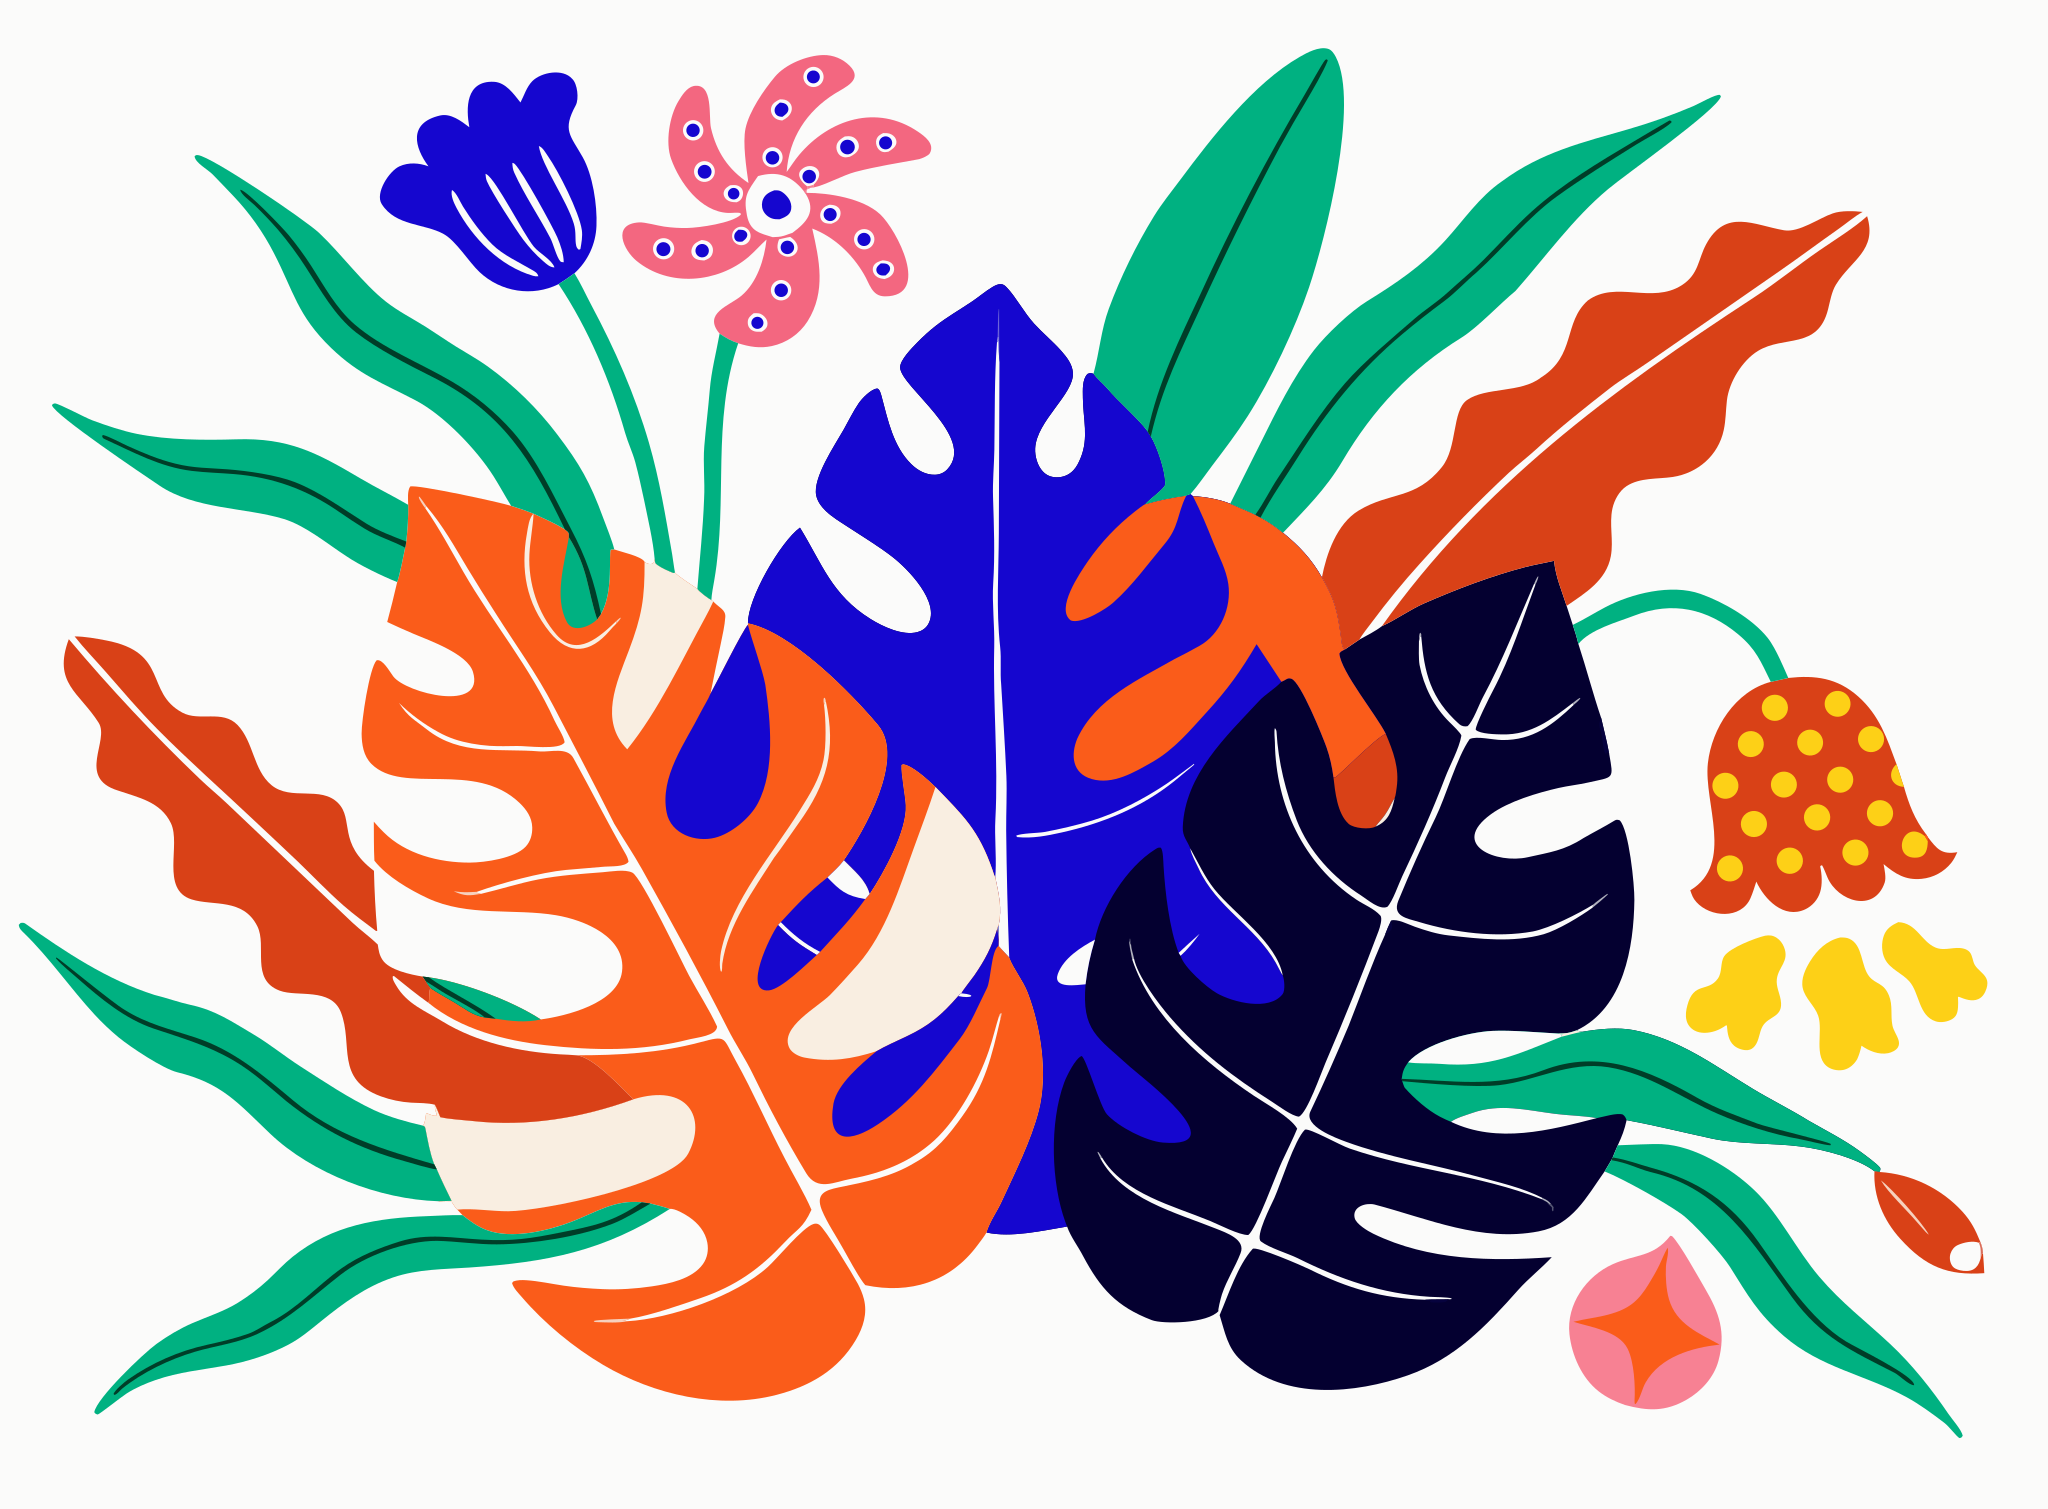

In [11]:
# 3a: Generate a detailed organic SVG
gen = await tool(
    "generate_svg",
    description="tropical leaves and flowers, botanical illustration",
    style_preset="organic",
    dimensions="800x600",
    model="nano-banana-pro",
    quality="high",
)
svg_path = gen["svg_path"]
print(f"Generated: {svg_path}")

# 3b: Validate the SVG before processing
val = await tool("inkscape_file_tool", operation="validate", input_path=svg_path)
print(f"Validation: valid={val.get('valid')}, issues={val.get('issues', [])}")

# 3c: Simplify paths (threshold=2.0 reduces node count while preserving shape)
simplified_path = svg_path.replace(".svg", "_simplified.svg")
simp = await tool("inkscape_vector_tool", operation="path_simplify",
                  input_path=svg_path, output_path=simplified_path, threshold=2.0)
print(f"\nSimplification: {simp}")

# 3d: Export to PDF
pdf_path = svg_path.replace(".svg", ".pdf")
conv = await tool("inkscape_file_tool", operation="convert",
                  input_path=simplified_path if Path(simplified_path).exists() else svg_path,
                  output_path=pdf_path, format="pdf")
print(f"PDF export:     {conv}")

show_svg(svg_path)

---
## Biology Examples — Scientific Figures with inkscape-mcp

Three biology-themed examples showing how portmanteau tools combine into real scientific
workflows. All use only tools verified as fully operational.

| Example | Tools used | Scientific use-case |
|---|---|---|
| B1 | `generate_svg` × 3 → Python compose → `inkscape_file convert` | Multi-panel DNA repair figure |
| B2 | `generate_svg` → `path_simplify` → `path_clean` → `inkscape_analysis` → multi-format export | Journal-ready Koch's Postulates diagram |
| B3 | `generate_svg` + `inkscape_vector generate_barcode_qr` → Python merge → `render_preview` | Lab protocol diagram with QR code |


---
### Example B1 — Three DNA Repair Pathways: multi-panel scientific figure

Generates three separate scientific diagrams (HR, NHEJ, SSA), validates each,
then **composes them side-by-side into a single publication-ready SVG panel**
using Python's built-in `xml.etree` — no stub tools needed.
Finally exports the composite to PDF for journal submission.

> **Biology context:** In yeast, double-strand DNA breaks are repaired by three
> main pathways: Homologous Recombination (HR), Non-Homologous End Joining (NHEJ),
> and Single-Strand Annealing (SSA). Each has distinct fidelity and cell-cycle requirements.


[03/15/26 19:50:51] INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=33267;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=535755;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in technical style...', 'extra': None}                                

[03/15/26 19:51:27] INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=87559;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=844667;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_195051_6398034f_500x400.svg', 'extra': None}                          

✅ HR   → ai_20260315_195051_6398034f_500x400.svg


                    INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=380654;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=771995;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in technical style...', 'extra': None}                                

[03/15/26 19:52:01] INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=654092;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=535932;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_195127_4fc60080_500x400.svg', 'extra': None}                          

✅ NHEJ → ai_20260315_195127_4fc60080_500x400.svg


                    INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=215058;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=735973;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in technical style...', 'extra': None}                                

[03/15/26 19:52:39] INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=127204;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=917278;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_195201_72b1b68a_500x400.svg', 'extra': None}                          

✅ SSA  → ai_20260315_195201_72b1b68a_500x400.svg
   HR valid=None  None×None
   NHEJ valid=None  None×None
   SSA valid=None  None×None

✅ Composite SVG → generated_svgs/dna_repair_pathways_composite.svg
📄 PDF export: Converted generated_svgs/dna_repair_pathways_composite.svg to generated_svgs/dna_repair_pathways_composite.pdf


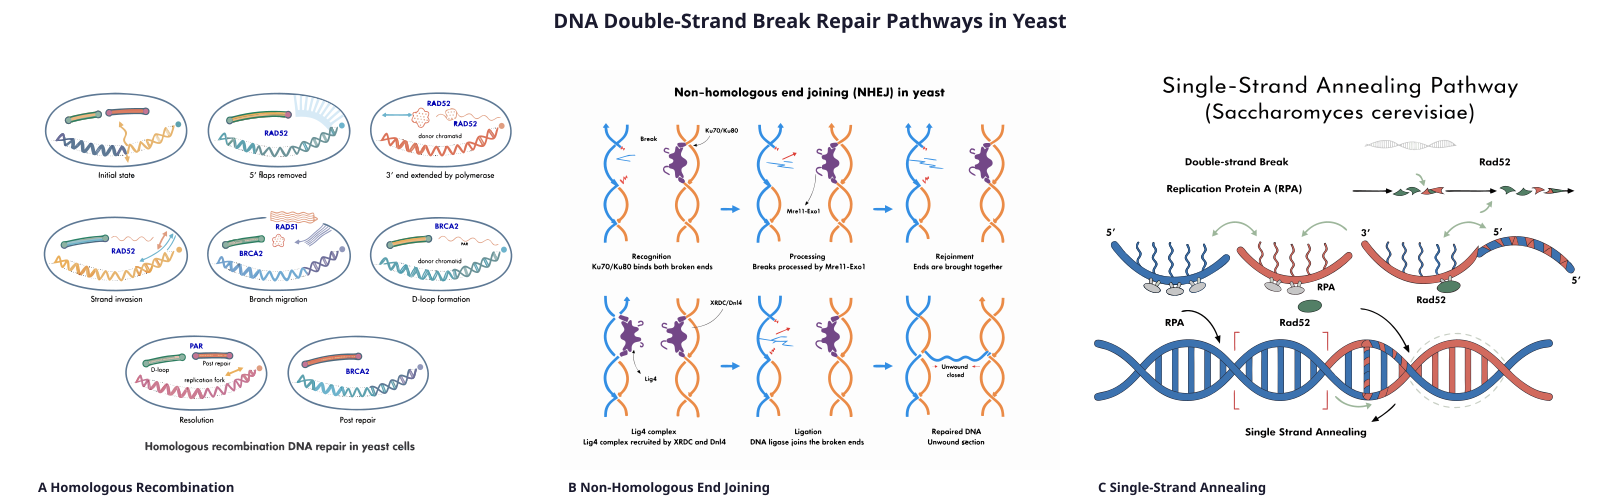

In [12]:
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import SVG, display

# ── B1a: Generate three pathway diagrams ──────────────────────────────────
descriptions = {
    "hr":   "homologous recombination DNA repair in yeast, showing strand invasion "
            "and D-loop formation, scientific diagram, labeled steps",
    "nhej": "non-homologous end joining DNA repair in yeast, showing Ku70/Ku80 "
            "binding broken DNA ends, scientific diagram, labeled steps",
    "ssa":  "single-strand annealing DNA repair in yeast, showing RPA and Rad52 "
            "mediated annealing of complementary strands, scientific diagram",
}

paths = {}
for key, desc in descriptions.items():
    try:
        result = await tool(
            "generate_svg",
            description=desc,
            style_preset="technical",
            dimensions="500x400",
            model="nano-banana-pro",
            quality="high",
        )
        paths[key] = result["svg_path"]
        print(f"✅ {key.upper():4s} → {Path(paths[key]).name}")
    except RuntimeError as e:
        print(f"❌ {key.upper():4s} → {e}")

# ── B1b: Validate each panel ─────────────────────────────────────────────
for key, p in paths.items():
    v = await tool("inkscape_file_tool", operation="validate", input_path=p)
    dims = await tool("inkscape_analysis_tool", operation="dimensions", input_path=p)
    print(f"   {key.upper()} valid={v.get('valid')}  "
          f"{dims.get('width')}×{dims.get('height')}")

# ── B1c: Compose into a single side-by-side SVG ───────────────────────────
PANEL_W, PANEL_H, GAP = 500, 400, 30
labels = {"hr": "A  Homologous Recombination",
          "nhej": "B  Non-Homologous End Joining",
          "ssa": "C  Single-Strand Annealing"}
total_w = PANEL_W * 3 + GAP * 4
total_h = PANEL_H + GAP * 2 + 40  # +40 for label row

ET.register_namespace("", "http://www.w3.org/2000/svg")
NS = "http://www.w3.org/2000/svg"

root = ET.Element(f"{{{NS}}}svg", {
    "width": str(total_w),
    "height": str(total_h),
    "viewBox": f"0 0 {total_w} {total_h}",
})

# White background
ET.SubElement(root, f"{{{NS}}}rect",
    {"width": str(total_w), "height": str(total_h), "fill": "white"})

# Title
title = ET.SubElement(root, f"{{{NS}}}text", {
    "x": str(total_w // 2), "y": "28",
    "text-anchor": "middle",
    "font-family": "sans-serif", "font-size": "20",
    "font-weight": "bold", "fill": "#1a1a2e",
})
title.text = "DNA Double-Strand Break Repair Pathways in Yeast"

for i, (key, p) in enumerate(paths.items()):
    x_off = GAP + i * (PANEL_W + GAP)
    y_off = GAP + 40

    # Parse inner SVG and embed as <g> with a translate transform
    try:
        inner = ET.parse(p).getroot()
        inner_vb = inner.get("viewBox", f"0 0 {PANEL_W} {PANEL_H}")
        # Wrap in a scaled group
        g = ET.SubElement(root, f"{{{NS}}}g", {
            "transform": f"translate({x_off},{y_off})",
        })
        # Scale inner content to PANEL_W x PANEL_H
        scale_g = ET.SubElement(g, f"{{{NS}}}g")
        vb_parts = inner_vb.split()
        if len(vb_parts) == 4:
            sx = PANEL_W / float(vb_parts[2]) if float(vb_parts[2]) else 1
            sy = PANEL_H / float(vb_parts[3]) if float(vb_parts[3]) else 1
            scale_g.set("transform", f"scale({sx:.4f},{sy:.4f})")
        for child in inner:
            scale_g.append(child)
    except Exception as e:
        # Fallback: just draw a placeholder rect
        ET.SubElement(root, f"{{{NS}}}rect", {
            "x": str(x_off), "y": str(y_off),
            "width": str(PANEL_W), "height": str(PANEL_H),
            "fill": "#f0f4f8", "stroke": "#4a6fa5", "stroke-width": "2",
        })
        err_t = ET.SubElement(root, f"{{{NS}}}text", {
            "x": str(x_off + PANEL_W // 2), "y": str(y_off + PANEL_H // 2),
            "text-anchor": "middle", "font-size": "14", "fill": "#666",
        })
        err_t.text = f"[{key.upper()}]"

    # Panel label
    lbl = ET.SubElement(root, f"{{{NS}}}text", {
        "x": str(x_off + 8), "y": str(y_off + PANEL_H + 22),
        "font-family": "sans-serif", "font-size": "13",
        "font-weight": "bold", "fill": "#1a1a2e",
    })
    lbl.text = labels[key]

# ── B1d: Save composite ───────────────────────────────────────────────────
out_dir = Path(paths["hr"]).parent
composite_path = str(out_dir / "dna_repair_pathways_composite.svg")
ET.ElementTree(root).write(composite_path, encoding="unicode", xml_declaration=False)
print(f"\n✅ Composite SVG → {composite_path}")

# ── B1e: Export to PDF for journal submission ─────────────────────────────
pdf_path = composite_path.replace(".svg", ".pdf")
conv = await tool("inkscape_file_tool", operation="convert",
                  input_path=composite_path, output_path=pdf_path, format="pdf")
print(f"📄 PDF export: {conv.get('message', conv)}")

# ── B1f: Display the composite ───────────────────────────────────────────
display(SVG(filename=composite_path))


---
### Example B2 — Koch's Postulates: journal-ready diagram with QA pipeline

Generates a Koch's Postulates diagram, runs `path_simplify` and `path_clean`
to reduce complexity (important for journal figure file-size limits), compares
statistics before and after, then exports to **PNG** (web/presentation) and
**EPS** (journal submission) from a single source SVG.

> **Biology context:** Koch's Postulates (1884) define the criteria for establishing
> a causal relationship between a microbe and a disease — still the gold standard
> for infectious disease research.


[03/15/26 19:52:42] INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=939926;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=546321;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in technical style...', 'extra': None}                                

[03/15/26 19:53:16] INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=914802;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=565399;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_195242_b79b332d_800x800.svg', 'extra': None}                          

Generated: generated_svgs/ai_20260315_195242_b79b332d_800x800.svg  (120.61 KB)

Before optimisation:
  objects    : None
  file size  : None bytes
  dimensions : None × None

After optimisation:
  objects    : None
  file size  : 0 bytes  (0.0% reduction)

── Deliverables ──────────────────────────────
  ✅  ai_20260315_195242_b79b332d_800x800_clean.svg   133,121 bytes
  ✅  ai_20260315_195242_b79b332d_800x800_96dpi.png   367,555 bytes
  ✅  ai_20260315_195242_b79b332d_800x800_300dpi.png  1,337,451 bytes
  ✅  ai_20260315_195242_b79b332d_800x800.eps         119,668 bytes


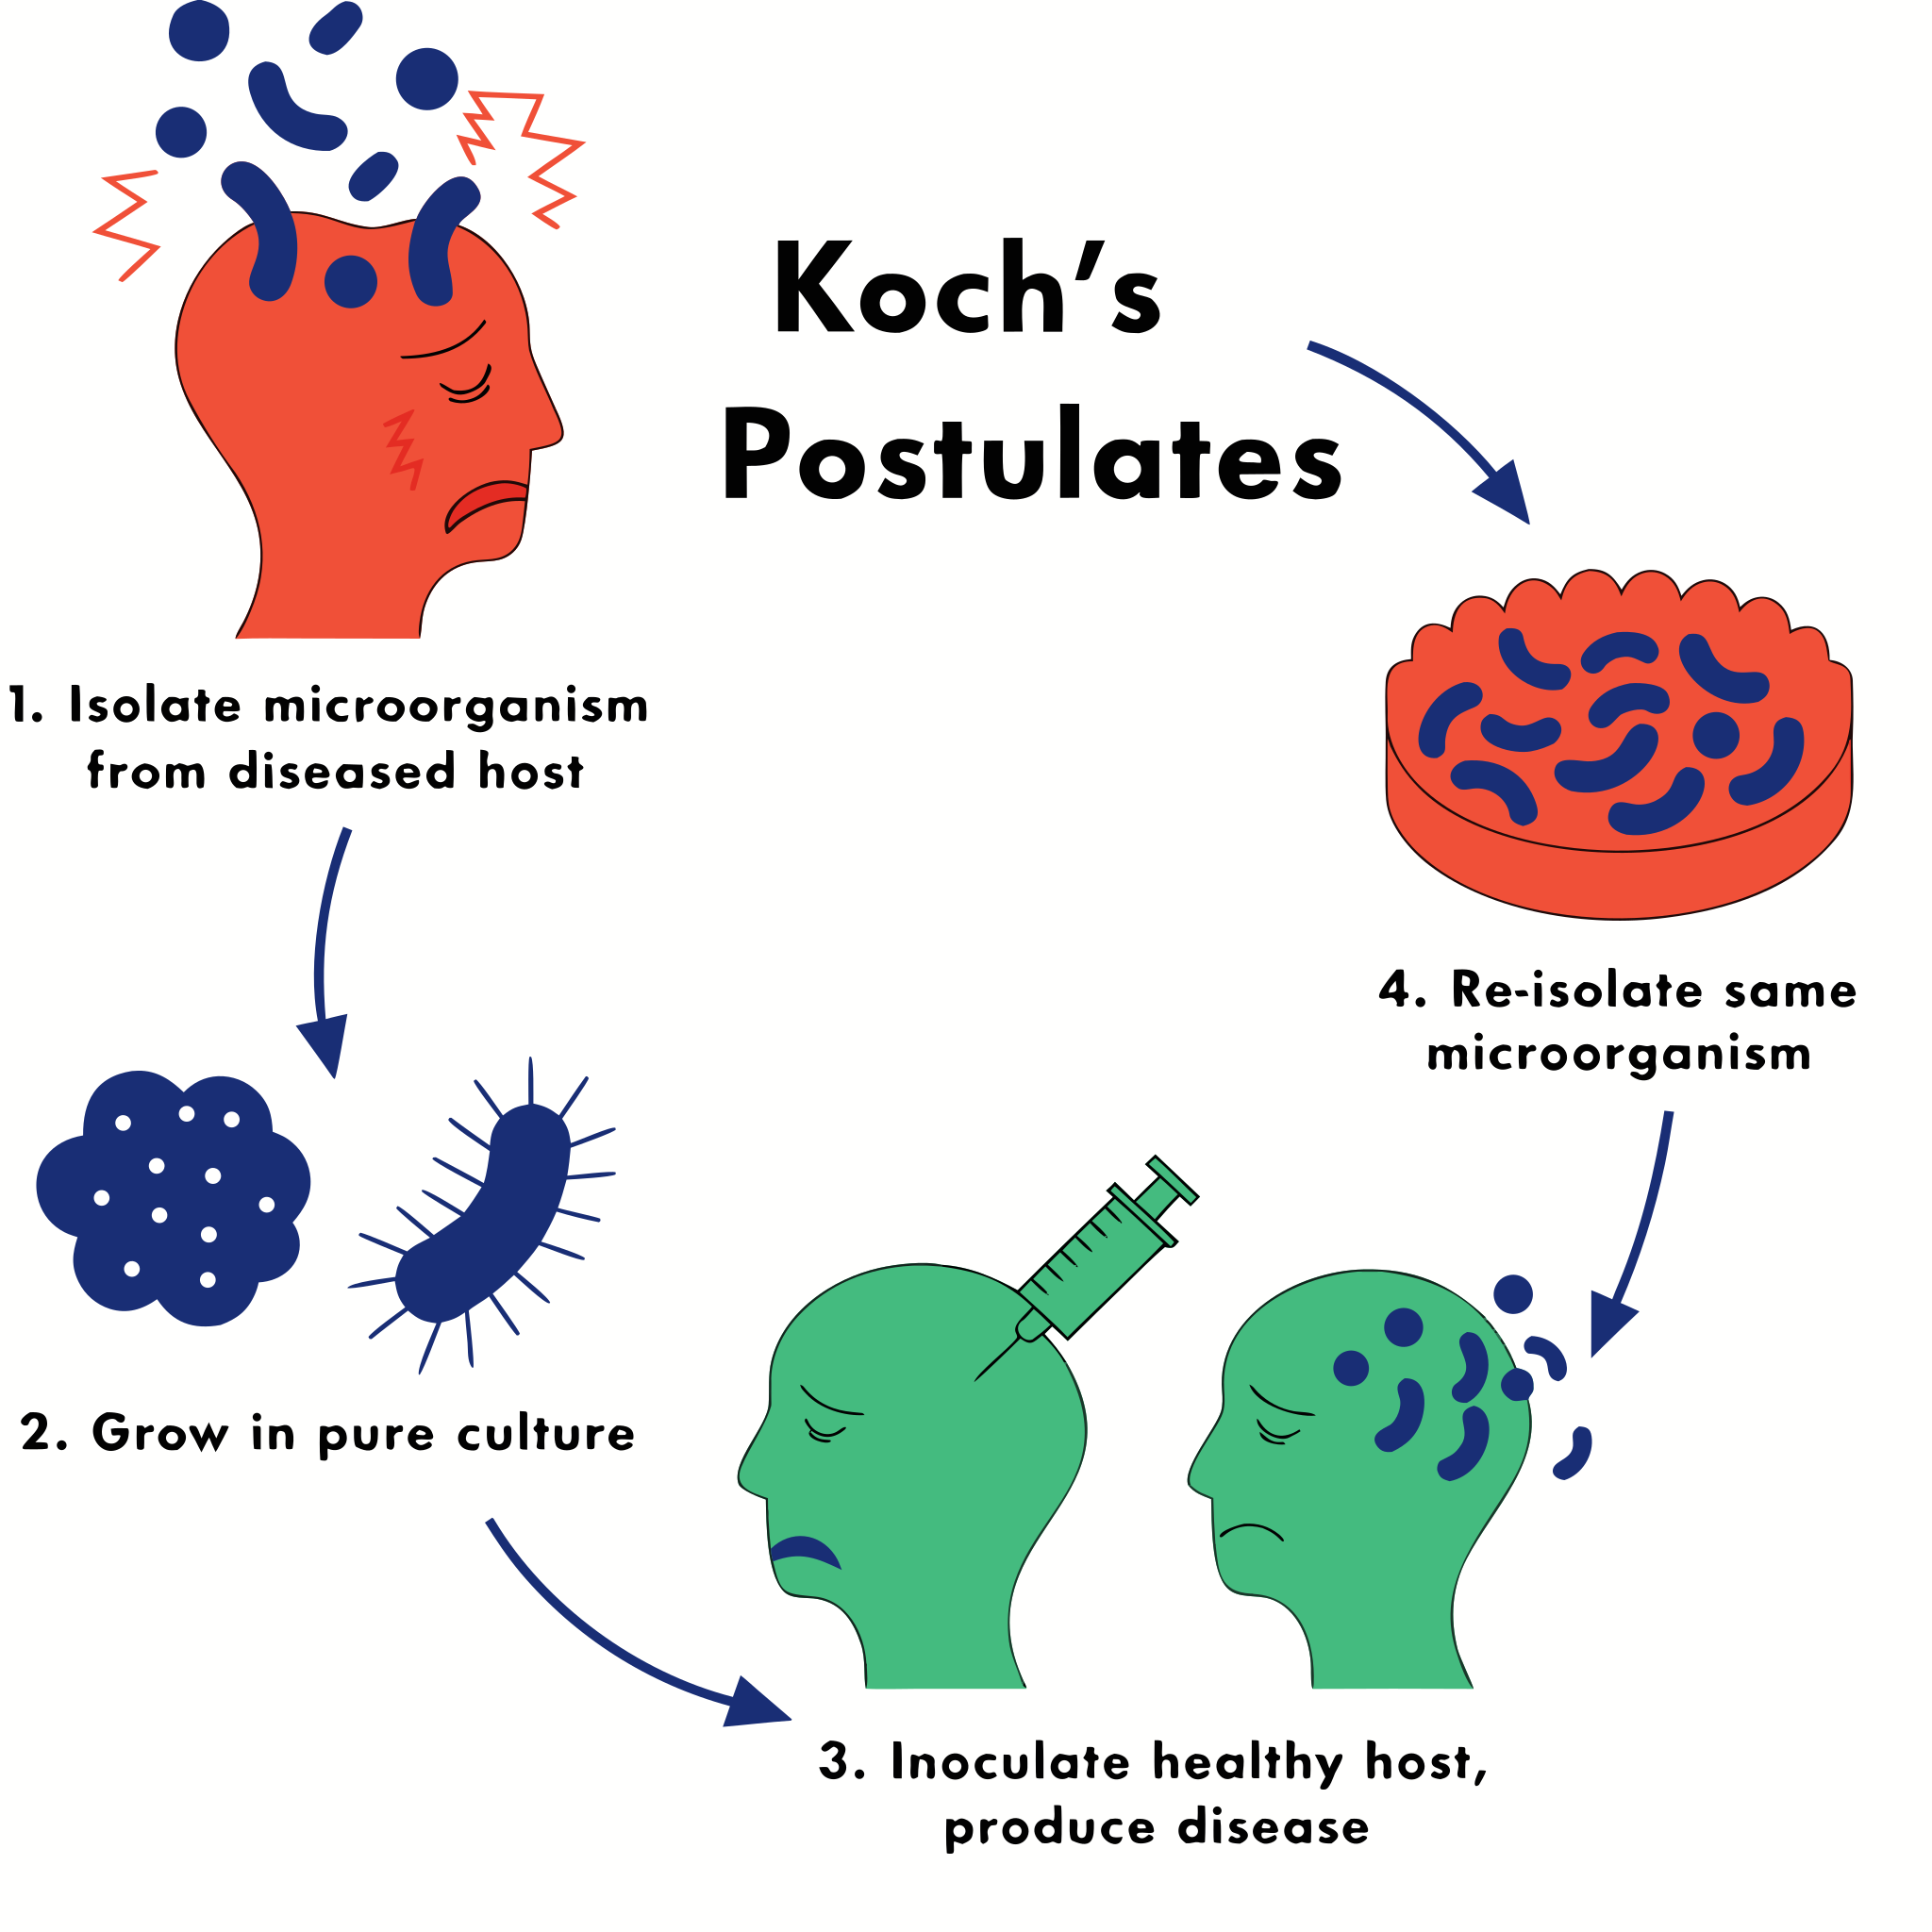

In [13]:
from pathlib import Path
from IPython.display import SVG, display

# ── B2a: Generate the diagram ─────────────────────────────────────────────
gen = await tool(
    "generate_svg",
    description=(
        "Koch's postulates illustrated as a four-step circular diagram: "
        "1) isolate microorganism from diseased host, "
        "2) grow in pure culture, "
        "3) inoculate healthy host produces disease, "
        "4) re-isolate same microorganism. "
        "Scientific infographic style, arrows between steps, yeast/bacteria icons"
    ),
    style_preset="technical",
    dimensions="800x800",
    model="nano-banana-pro",
    quality="high",
)
src = gen["svg_path"]
stem = Path(src).stem
out  = Path(src).parent
print(f"Generated: {src}  ({gen.get('file_size_kb','?')} KB)")

# ── B2b: Baseline statistics ──────────────────────────────────────────────
stats_before = await tool("inkscape_analysis_tool", operation="statistics", input_path=src)
print(f"\nBefore optimisation:")
print(f"  objects    : {stats_before.get('object_count')}")
print(f"  file size  : {stats_before.get('file_size_bytes')} bytes")
print(f"  dimensions : {stats_before.get('width')} × {stats_before.get('height')}")

# ── B2c: Simplify paths (threshold=1.5 — good balance for scientific figs) ─
simplified = str(out / f"{stem}_simplified.svg")
await tool("inkscape_vector_tool", operation="path_simplify",
           input_path=src, output_path=simplified, threshold=1.5)

# ── B2d: Clean up empty groups and artefacts ─────────────────────────────
cleaned = str(out / f"{stem}_clean.svg")
await tool("inkscape_vector_tool", operation="path_clean",
           input_path=simplified if Path(simplified).exists() else src,
           output_path=cleaned)

working = cleaned if Path(cleaned).exists() else src

# ── B2e: Post-optimisation statistics (QA comparison) ────────────────────
stats_after = await tool("inkscape_analysis_tool", operation="statistics", input_path=working)
size_before = stats_before.get("file_size_bytes", 0)
size_after  = stats_after.get("file_size_bytes", 0)
reduction   = (1 - size_after / size_before) * 100 if size_before else 0
print(f"\nAfter optimisation:")
print(f"  objects    : {stats_after.get('object_count')}")
print(f"  file size  : {size_after} bytes  ({reduction:.1f}% reduction)")

# ── B2f: Export PNG (96 dpi, for presentations / web) ────────────────────
png_web = str(out / f"{stem}_96dpi.png")
await tool("inkscape_vector_tool", operation="render_preview",
           input_path=working, output_path=png_web, dpi=96)

# ── B2g: Export PNG at 300 dpi (journal figure quality) ──────────────────
png_hq = str(out / f"{stem}_300dpi.png")
await tool("inkscape_vector_tool", operation="render_preview",
           input_path=working, output_path=png_hq, dpi=300)

# ── B2h: Export EPS (required by many journals e.g. Nature, Science) ─────
eps_path = str(out / f"{stem}.eps")
await tool("inkscape_file_tool", operation="convert",
           input_path=working, output_path=eps_path, format="eps")

# ── B2i: Summary ─────────────────────────────────────────────────────────
print("\n── Deliverables ──────────────────────────────")
for p in [working, png_web, png_hq, eps_path]:
    sz = Path(p).stat().st_size if Path(p).exists() else 0
    print(f"  {'✅' if sz else '❌'}  {Path(p).name:<45s}  {sz:>8,} bytes")

display(SVG(filename=working))


---
### Example B3 — Lab Protocol Diagram with QR Code

Generates a yeast transformation protocol flowchart, then uses
`inkscape_vector generate_barcode_qr` to create a QR code linking to a
protocol URL — a common need when sharing figures in lab presentations or
posters. The QR code is embedded into the diagram SVG using Python's
`xml.etree`, and a PNG at poster resolution (150 dpi) is exported.

> **Biology context:** QR codes on scientific figures let conference attendees
> instantly access full protocols, datasets, or supplementary materials by
> scanning with a phone.


[03/15/26 19:53:24] INFO     Received INFO from server: {'msg': '🤖 Generating AI SVG with            ]8;id=625698;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=235659;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             nano-banana-pro in technical style...', 'extra': None}                                

[03/15/26 19:54:03] INFO     Received INFO from server: {'msg': '✅ SVG generated successfully! Saved ]8;id=878639;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py\logging.py]8;;\:]8;id=11079;file:///usr/local/lib/python3.12/site-packages/fastmcp/client/logging.py#44\44]8;;\
                             as: ai_20260315_195324_c11fd7ad_600x900.svg', 'extra': None}                          

Protocol diagram: generated_svgs/ai_20260315_195324_c11fd7ad_600x900.svg
QR code:          generated_svgs/protocol_qr.svg  exists=True
QR result: {'success': True, 'operation': 'generate_barcode_qr', 'message': 'QR code generated (inkscape-ext) for: https://www.protocols.io/view/high-efficiency-s-cerevisiae-lithium-acetate-trans-j4tcqwn.pdf', 'data': {'output_path': 'generated_svgs/protocol_qr.svg', 'data': 'https://www.protocols.io/view/high-efficiency-s-cerevisiae-lithium-acetate-trans-j4tcqwn.pdf', 'type': 'qr', 'generator': 'inkscape-ext'}, 'execution_time_ms': 464.7374153137207, 'error': ''}

✅ Annotated diagram → generated_svgs/ai_20260315_195324_c11fd7ad_600x900_with_qr.svg
   Valid: None  issues: []
   Poster PNG → generated_svgs/ai_20260315_195324_c11fd7ad_600x900_poster_150dpi.png  (645,871 bytes)


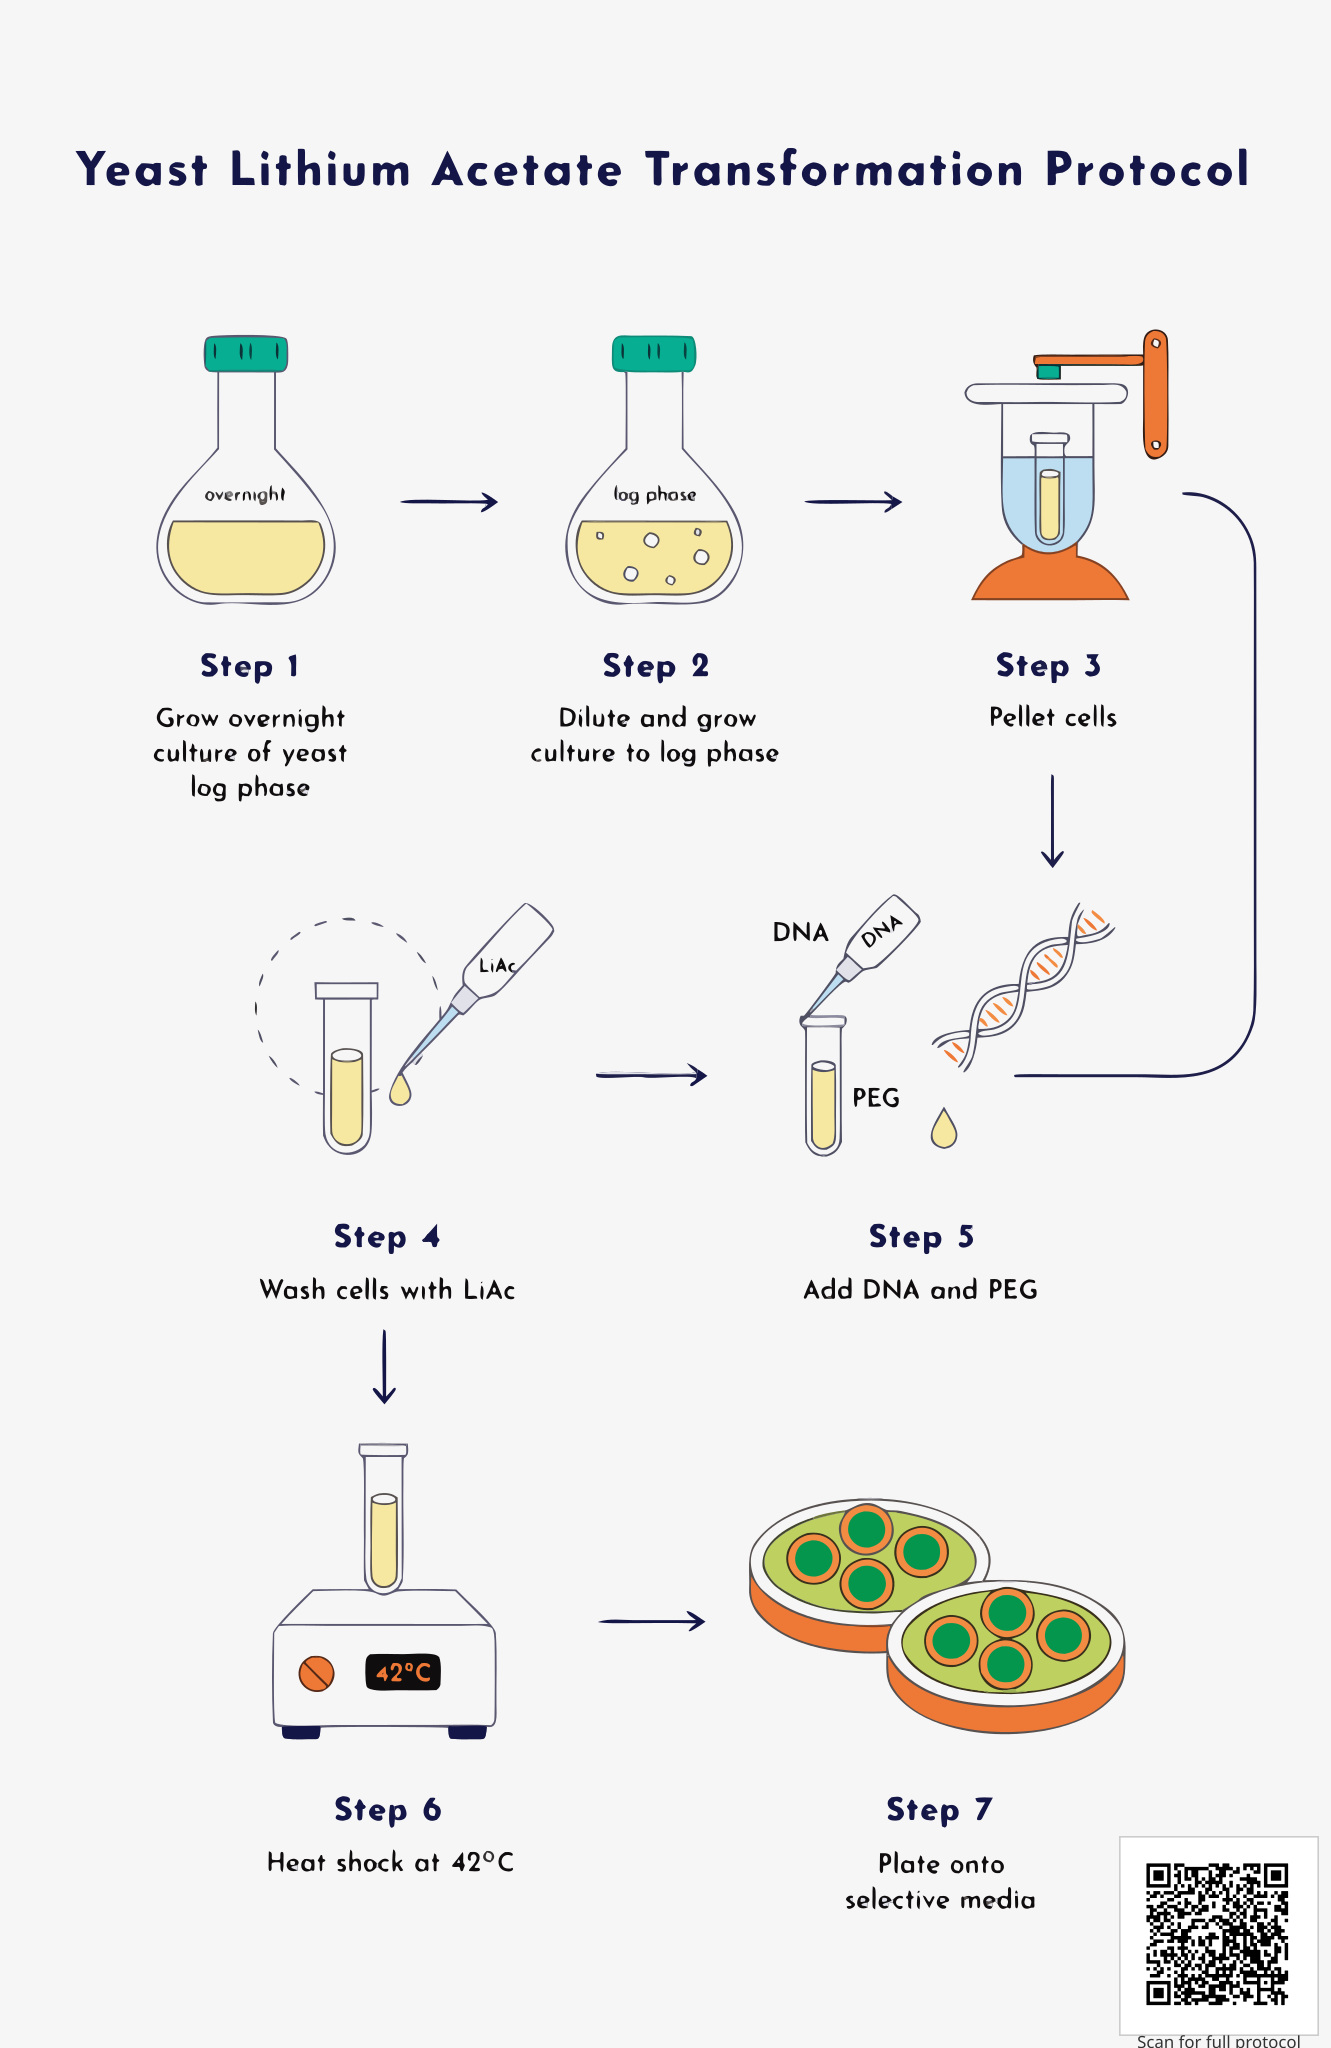

In [14]:
import xml.etree.ElementTree as ET
from pathlib import Path
from IPython.display import SVG, display

# ── B3a: Generate the protocol flowchart ─────────────────────────────────
gen = await tool(
    "generate_svg",
    description=(
        "yeast lithium acetate transformation protocol flowchart: "
        "step 1 grow overnight culture, step 2 dilute and grow to log phase, "
        "step 3 pellet cells, step 4 wash with LiAc, step 5 add DNA and PEG, "
        "step 6 heat shock at 42C, step 7 plate on selective media. "
        "Clean scientific infographic, numbered steps with arrows, minimal style"
    ),
    style_preset="technical",
    dimensions="600x900",
    model="nano-banana-pro",
    quality="high",
)
diagram_path = gen["svg_path"]
out = Path(diagram_path).parent
stem = Path(diagram_path).stem
print(f"Protocol diagram: {diagram_path}")

# ── B3b: Generate a QR code linking to a protocol repository ─────────────
qr_path = str(out / "protocol_qr.svg")
qr = await tool(
    "inkscape_vector_tool",
    operation="generate_barcode_qr",
    output_path=qr_path,
    barcode_data="https://www.protocols.io/view/high-efficiency-s-cerevisiae-lithium-acetate-trans-j4tcqwn.pdf",
)
print(f"QR code:          {qr_path}  exists={Path(qr_path).exists()}")
print(f"QR result: {qr}")

# ── B3c: Build a fresh composite SVG with a uniform coordinate system ───────
#
# WHY a fresh composite?
#   AI-generated SVGs (e.g. from Recraft) often have a non-square viewBox but a
#   rectangular viewport, combined with preserveAspectRatio="none" at the root.
#   This creates non-uniform coordinate scaling (sx ≠ sy).  If we tried to embed
#   a square QR code directly into that distorted space we would need to apply a
#   compensating scale transform — brittle and hard to maintain.
#
# SOLUTION — three-layer composite:
#   1. New root <svg>  width=comp_w  height=comp_h  viewBox="0 0 comp_w comp_h"
#      → sx = comp_w/comp_w = 1,  sy = comp_h/comp_h = 1  (perfectly uniform)
#   2. Diagram nested <svg> fills the full canvas with preserveAspectRatio="none"
#      → preserves the diagram's original visual appearance regardless of whether
#        its own viewBox aspect ratio matches the viewport
#   3. QR nested <svg> placed with equal width & height in the uniform space
#      → equal coordinate dimensions = equal rendered pixels = square QR

NS = "http://www.w3.org/2000/svg"
ET.register_namespace("", NS)

def _parse_dim(val, fallback):
    """Strip CSS unit suffixes and return float, or fallback on failure."""
    if val is None:
        return fallback
    try:
        return float(val.rstrip("px pt em rem %in cm mm").strip())
    except ValueError:
        return fallback

diagram_root = ET.parse(diagram_path).getroot()
qr_root      = ET.parse(qr_path).getroot()

# Composite canvas = diagram's physical viewport dimensions (px).
# These become the output file's rendered width/height.
comp_w = _parse_dim(diagram_root.get("width"),  600)
comp_h = _parse_dim(diagram_root.get("height"), 900)

# Root SVG: viewBox matches physical size → no scaling distortion.
composite = ET.Element(f"{{{NS}}}svg", {
    "width":   str(comp_w),
    "height":  str(comp_h),
    "viewBox": f"0 0 {comp_w} {comp_h}",
})

# ── Layer 1: embed the full diagram ──────────────────────────────────────
# Use the diagram's own viewBox so its internal coordinate system is respected.
# preserveAspectRatio="none" mirrors the original SVG's behaviour and ensures
# the diagram fills the composite canvas without letterboxing, even when the
# diagram's viewBox is square but the canvas is rectangular (or vice-versa).
diag_vb = diagram_root.get("viewBox") or f"0 0 {comp_w} {comp_h}"
diag_embed = ET.SubElement(composite, f"{{{NS}}}svg", {
    "x": "0", "y": "0",
    "width": str(comp_w), "height": str(comp_h),
    "viewBox": diag_vb,
    "preserveAspectRatio": "none",   # stretch to fill; matches original rendering
})
for child in diagram_root:
    diag_embed.append(child)

# ── Layer 2: embed the QR code ────────────────────────────────────────────
# In the uniform composite space (sx=sy=1), width==height guarantees a square
# rendered box — no compensating transforms required.
QR_SIZE = round(min(comp_w, comp_h) * 0.13)   # ~13 % of shorter dimension
PAD     = round(QR_SIZE * 0.15)                # white border around QR
x_qr    = comp_w - QR_SIZE - PAD              # bottom-right corner placement
y_qr    = comp_h - QR_SIZE - PAD

# Determine the QR SVG's intrinsic coordinate dimensions.
# segno produces width/height attributes but no viewBox; fall back to viewBox
# if only that is present (other SVG generators may behave differently).
qr_w = _parse_dim(qr_root.get("width"), None)
qr_h = _parse_dim(qr_root.get("height"), None)
if qr_w is None or qr_h is None:
    vb_parts = (qr_root.get("viewBox") or "0 0 200 200").split()
    qr_w = float(vb_parts[2]) if len(vb_parts) > 2 else 200
    qr_h = float(vb_parts[3]) if len(vb_parts) > 3 else 200

# White backing rectangle (visual border for the QR code).
ET.SubElement(composite, f"{{{NS}}}rect", {
    "x": str(x_qr - PAD // 2), "y": str(y_qr - PAD // 2),
    "width":  str(QR_SIZE + PAD), "height": str(QR_SIZE + PAD),
    "fill": "white", "stroke": "#cccccc", "stroke-width": "2",
})
# QR nested SVG: width==height in uniform space → always renders square.
# preserveAspectRatio="xMidYMid meet" is correct here because the QR viewBox
# is already square, so "meet" is effectively a no-op but makes intent clear.
qr_embed = ET.SubElement(composite, f"{{{NS}}}svg", {
    "x": str(x_qr), "y": str(y_qr),
    "width":  str(QR_SIZE),
    "height": str(QR_SIZE),
    "viewBox": f"0 0 {qr_w} {qr_h}",
    "preserveAspectRatio": "xMidYMid meet",  # no-op for square viewBox; documents intent
})
for child in qr_root:
    qr_embed.append(child)

ET.SubElement(composite, f"{{{NS}}}text", {
    "x": str(x_qr + QR_SIZE // 2),
    "y": str(y_qr + QR_SIZE + PAD),
    "text-anchor": "middle",
    "font-family": "sans-serif",
    "font-size": str(max(10, QR_SIZE // 10)),
    "fill": "#333",
}).text = "Scan for full protocol"

# ── B3d: Save the annotated diagram ──────────────────────────────────────
annotated_path = str(out / f"{stem}_with_qr.svg")
ET.ElementTree(composite).write(annotated_path, encoding="unicode", xml_declaration=False)
print(f"\n✅ Annotated diagram → {annotated_path}")

# ── B3e: Validate the final file ─────────────────────────────────────────
val = await tool("inkscape_file_tool", operation="validate", input_path=annotated_path)
print(f"   Valid: {val.get('valid')}  issues: {val.get('issues', [])}")

# ── B3f: Export at 150 dpi for conference poster ──────────────────────────
poster_png = str(out / f"{stem}_poster_150dpi.png")
await tool("inkscape_vector_tool", operation="render_preview",
           input_path=annotated_path, output_path=poster_png, dpi=150)
sz = Path(poster_png).stat().st_size if Path(poster_png).exists() else 0
print(f"   Poster PNG → {poster_png}  ({sz:,} bytes)")

display(SVG(filename=annotated_path))
